# Notebook exploring outliers using pyod

In [ ]:
import platform
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print(os.getcwd())
system_name = platform.system()


pd.set_option("display.max_columns", None)

from helpers.dataframeBuilderBAQ import get_distances_indices_sklearn_NearestNeighbors
from helpers.dataframeBuilderBAQ import neighbors_distances_indices_to_readable_df
from helpers.dataframeBuilderBAQ import add_days_ago
from helpers.dataframeBuilderBAQ import add_version
from helpers.dataframeBuilderBAQ import add_candidate
from helpers.dataframeBuilderBAQ import load_df_candidate


from sklearn.preprocessing import MinMaxScaler

/home/miked/code/dep2-g2/anomalies/BAQ/scripts


In [2]:
LOTS_OF_TRAINING_TIME = False # Run all
RUN_OPTIONAL = False # Just skip a few

## LOF is proximity based

So anything that has to do with distances
In that aspect, I believe using the exented matrix is good

In [3]:
from pyod.models.copod import COPOD
from pyod.models.abod import ABOD
from pyod.models.lof import LOF
from pyod.models.iforest import IForest
# from pyod.models.ae1svm import AE1SVM
from pyod.models.knn import KNN
from pyod.models.iforest import IForest
from pyod.models.dif import DIF


In [4]:
df_candidate = load_df_candidate()
df_candidate

,CandidateKey,ID,InstanceID,Organisation,ChosenLanguage,ChosenGender,Gender,Qualification
0,14,1,4,B2BABE21-1705-4750-AE99-8D1316755876,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
2,23,2,3,4B79F6DC-F833-4721-82E3-DF6F09AE8EA2,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,NaN,Gender_Male,Qualification_Unknown
10,62,6,2,FDE03D4F-9C9B-4B36-9C0C-F5296C6772F1,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Bachelor
12,84,8,4,B2BABE21-1705-4750-AE99-8D1316755876,65CAFEA9-CF49-43ED-99AA-83AFE0539978,Gender_Male,Gender_Male,Qualification_Unknown
14,94,9,4,B2BABE21-1705-4750-AE99-8D1316755876,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
...,...,...,...,...,...,...,...,...
2292620,50830491,5083049,1,D4A15280-CD15-4298-A450-556703C30E00,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
2292622,50830511,5083051,1,D4A15280-CD15-4298-A450-556703C30E00,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
2292624,50830531,5083053,1,D4A15280-CD15-4298-A450-556703C30E00,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown
2292627,50830561,5083056,1,D4A15280-CD15-4298-A450-556703C30E00,FADAABC8-26DD-458B-B07E-BF96B4B3FCED,Gender_Male,Gender_Male,Qualification_Unknown


In [5]:
df = pd.read_csv("csv/preprocessed_data.csv")
df.index = df["TestKey"]
df, df_test = add_days_ago(df)
df

,TestKey,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q4_A1_norm,Q4_A2_norm,Q4_A3_norm,Q4_A4_norm,Q4_A5_norm,Q5_A1_norm,Q5_A2_norm,Q5_A3_norm,Q5_A4_norm,Q5_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q9_A1_norm,Q9_A2_norm,Q9_A3_norm,Q9_A4_norm,Q9_A5_norm,Q10_A1_norm,Q10_A2_norm,Q10_A3_norm,Q10_A4_norm,Q10_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q14_A1_norm,Q14_A2_norm,Q14_A3_norm,Q14_A4_norm,Q14_A5_norm,Q15_A1_norm,Q15_A2_norm,Q15_A3_norm,Q15_A4_norm,Q15_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q19_A1_norm,Q19_A2_norm,Q19_A3_norm,Q19_A4_norm,Q19_A5_norm,Q20_A1_norm,Q20_A2_norm,Q20_A3_norm,Q20_A4_norm,Q20_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q23_A1_norm,Q23_A2_norm,Q23_A3_norm,Q23_A4_norm,Q23_A5_norm,Q24_A1_norm,Q24_A2_norm,Q24_A3_norm,Q24_A4_norm,Q24_A5_norm,Q25_A1_norm,Q25_A2_norm,Q25_A3_norm,Q25_A4_norm,Q25_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q28_A1_norm,Q28_A2_norm,Q28_A3_norm,Q28_A4_norm,Q28_A5_norm,Q29_A1_norm,Q29_A2_norm,Q29_A3_norm,Q29_A4_norm,Q29_A5_norm,Q30_A1_norm,Q30_A2_norm,Q30_A3_norm,Q30_A4_norm,Q30_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q33_A1_norm,Q33_A2_norm,Q33_A3_norm,Q33_A4_norm,Q33_A5_norm,Q34_A1_norm,Q34_A2_norm,Q34_A3_norm,Q34_A4_norm,Q34_A5_norm,Q35_A1_norm,Q35_A2_norm,Q35_A3_norm,Q35_A4_norm,Q35_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q38_A1_norm,Q38_A2_norm,Q38_A3_norm,Q38_A4_norm,Q38_A5_norm,Q39_A1_norm,Q39_A2_norm,Q39_A3_norm,Q39_A4_norm,Q39_A5_norm,Q40_A1_norm,Q40_A2_norm,Q40_A3_norm,Q40_A4_norm,Q40_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q43_A1_norm,Q43_A2_norm,Q43_A3_norm,Q43_A4_norm,Q43_A5_norm,Q44_A1_norm,Q44_A2_norm,Q44_A3_norm,Q44_A4_norm,Q44_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q48_A1_norm,Q48_A2_norm,Q48_A3_norm,Q48_A4_norm,Q48_A5_norm,Q49_A1_norm,Q49_A2_norm,Q49_A3_norm,Q49_A4_norm,Q49_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q53_A1_norm,Q53_A2_norm,Q53_A3_norm,Q53_A4_norm,Q53_A5_norm,Q54_A1_norm,Q54_A2_norm,Q54_A3_norm,Q54_A4_norm,Q54_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q58_A1_norm,Q58_A2_norm,Q58_A3_norm,Q58_A4_norm,Q58_A5_norm,Q59_A1_norm,Q59_A2_norm,Q59_A3_norm,Q59_A4_norm,Q59_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q63_A1_norm,Q63_A2_norm,Q63_A3_norm,Q63_A4_norm,Q63_A5_norm,Q0_A1_ips,Q0_A2_ips,Q0_A3_ips,Q0_A4_ips,Q0_A5_ips,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q4_A1_ips,Q4_A2_ips,Q4_A3_ips,Q4_A4_ips,Q4_A5_ips,Q5_A1_ips,Q5_A2_ips,Q5_A3_ips,Q5_A4_ips,Q5_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q

In [6]:
df.loc[df[df["DaysAgo"] == 0].index, (df[df["DaysAgo"] == 0] != 0).any(axis=0)]

""
TestKey


In [7]:
df = add_candidate(df, df_test=df_test)
df = add_version(df, df_test=df_test, one_hot=True)
df

VersionNumber
v2.0    9830
v2.1    5295
v1.0    3562
v1.2    1858
v1.1     578
Name: count, dtype: int64


,TestKey,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q4_A1_norm,Q4_A2_norm,Q4_A3_norm,Q4_A4_norm,Q4_A5_norm,Q5_A1_norm,Q5_A2_norm,Q5_A3_norm,Q5_A4_norm,Q5_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q9_A1_norm,Q9_A2_norm,Q9_A3_norm,Q9_A4_norm,Q9_A5_norm,Q10_A1_norm,Q10_A2_norm,Q10_A3_norm,Q10_A4_norm,Q10_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q14_A1_norm,Q14_A2_norm,Q14_A3_norm,Q14_A4_norm,Q14_A5_norm,Q15_A1_norm,Q15_A2_norm,Q15_A3_norm,Q15_A4_norm,Q15_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q19_A1_norm,Q19_A2_norm,Q19_A3_norm,Q19_A4_norm,Q19_A5_norm,Q20_A1_norm,Q20_A2_norm,Q20_A3_norm,Q20_A4_norm,Q20_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q23_A1_norm,Q23_A2_norm,Q23_A3_norm,Q23_A4_norm,Q23_A5_norm,Q24_A1_norm,Q24_A2_norm,Q24_A3_norm,Q24_A4_norm,Q24_A5_norm,Q25_A1_norm,Q25_A2_norm,Q25_A3_norm,Q25_A4_norm,Q25_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q28_A1_norm,Q28_A2_norm,Q28_A3_norm,Q28_A4_norm,Q28_A5_norm,Q29_A1_norm,Q29_A2_norm,Q29_A3_norm,Q29_A4_norm,Q29_A5_norm,Q30_A1_norm,Q30_A2_norm,Q30_A3_norm,Q30_A4_norm,Q30_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q33_A1_norm,Q33_A2_norm,Q33_A3_norm,Q33_A4_norm,Q33_A5_norm,Q34_A1_norm,Q34_A2_norm,Q34_A3_norm,Q34_A4_norm,Q34_A5_norm,Q35_A1_norm,Q35_A2_norm,Q35_A3_norm,Q35_A4_norm,Q35_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q38_A1_norm,Q38_A2_norm,Q38_A3_norm,Q38_A4_norm,Q38_A5_norm,Q39_A1_norm,Q39_A2_norm,Q39_A3_norm,Q39_A4_norm,Q39_A5_norm,Q40_A1_norm,Q40_A2_norm,Q40_A3_norm,Q40_A4_norm,Q40_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q43_A1_norm,Q43_A2_norm,Q43_A3_norm,Q43_A4_norm,Q43_A5_norm,Q44_A1_norm,Q44_A2_norm,Q44_A3_norm,Q44_A4_norm,Q44_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q48_A1_norm,Q48_A2_norm,Q48_A3_norm,Q48_A4_norm,Q48_A5_norm,Q49_A1_norm,Q49_A2_norm,Q49_A3_norm,Q49_A4_norm,Q49_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q53_A1_norm,Q53_A2_norm,Q53_A3_norm,Q53_A4_norm,Q53_A5_norm,Q54_A1_norm,Q54_A2_norm,Q54_A3_norm,Q54_A4_norm,Q54_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q58_A1_norm,Q58_A2_norm,Q58_A3_norm,Q58_A4_norm,Q58_A5_norm,Q59_A1_norm,Q59_A2_norm,Q59_A3_norm,Q59_A4_norm,Q59_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q63_A1_norm,Q63_A2_norm,Q63_A3_norm,Q63_A4_norm,Q63_A5_norm,Q0_A1_ips,Q0_A2_ips,Q0_A3_ips,Q0_A4_ips,Q0_A5_ips,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q4_A1_ips,Q4_A2_ips,Q4_A3_ips,Q4_A4_ips,Q4_A5_ips,Q5_A1_ips,Q5_A2_ips,Q5_A3_ips,Q5_A4_ips,Q5_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q

In [8]:
df.drop(columns="TestKey", inplace=True)
df

,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q4_A1_norm,Q4_A2_norm,Q4_A3_norm,Q4_A4_norm,Q4_A5_norm,Q5_A1_norm,Q5_A2_norm,Q5_A3_norm,Q5_A4_norm,Q5_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q9_A1_norm,Q9_A2_norm,Q9_A3_norm,Q9_A4_norm,Q9_A5_norm,Q10_A1_norm,Q10_A2_norm,Q10_A3_norm,Q10_A4_norm,Q10_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q14_A1_norm,Q14_A2_norm,Q14_A3_norm,Q14_A4_norm,Q14_A5_norm,Q15_A1_norm,Q15_A2_norm,Q15_A3_norm,Q15_A4_norm,Q15_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q19_A1_norm,Q19_A2_norm,Q19_A3_norm,Q19_A4_norm,Q19_A5_norm,Q20_A1_norm,Q20_A2_norm,Q20_A3_norm,Q20_A4_norm,Q20_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q23_A1_norm,Q23_A2_norm,Q23_A3_norm,Q23_A4_norm,Q23_A5_norm,Q24_A1_norm,Q24_A2_norm,Q24_A3_norm,Q24_A4_norm,Q24_A5_norm,Q25_A1_norm,Q25_A2_norm,Q25_A3_norm,Q25_A4_norm,Q25_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q28_A1_norm,Q28_A2_norm,Q28_A3_norm,Q28_A4_norm,Q28_A5_norm,Q29_A1_norm,Q29_A2_norm,Q29_A3_norm,Q29_A4_norm,Q29_A5_norm,Q30_A1_norm,Q30_A2_norm,Q30_A3_norm,Q30_A4_norm,Q30_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q33_A1_norm,Q33_A2_norm,Q33_A3_norm,Q33_A4_norm,Q33_A5_norm,Q34_A1_norm,Q34_A2_norm,Q34_A3_norm,Q34_A4_norm,Q34_A5_norm,Q35_A1_norm,Q35_A2_norm,Q35_A3_norm,Q35_A4_norm,Q35_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q38_A1_norm,Q38_A2_norm,Q38_A3_norm,Q38_A4_norm,Q38_A5_norm,Q39_A1_norm,Q39_A2_norm,Q39_A3_norm,Q39_A4_norm,Q39_A5_norm,Q40_A1_norm,Q40_A2_norm,Q40_A3_norm,Q40_A4_norm,Q40_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q43_A1_norm,Q43_A2_norm,Q43_A3_norm,Q43_A4_norm,Q43_A5_norm,Q44_A1_norm,Q44_A2_norm,Q44_A3_norm,Q44_A4_norm,Q44_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q48_A1_norm,Q48_A2_norm,Q48_A3_norm,Q48_A4_norm,Q48_A5_norm,Q49_A1_norm,Q49_A2_norm,Q49_A3_norm,Q49_A4_norm,Q49_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q53_A1_norm,Q53_A2_norm,Q53_A3_norm,Q53_A4_norm,Q53_A5_norm,Q54_A1_norm,Q54_A2_norm,Q54_A3_norm,Q54_A4_norm,Q54_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q58_A1_norm,Q58_A2_norm,Q58_A3_norm,Q58_A4_norm,Q58_A5_norm,Q59_A1_norm,Q59_A2_norm,Q59_A3_norm,Q59_A4_norm,Q59_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q63_A1_norm,Q63_A2_norm,Q63_A3_norm,Q63_A4_norm,Q63_A5_norm,Q0_A1_ips,Q0_A2_ips,Q0_A3_ips,Q0_A4_ips,Q0_A5_ips,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q4_A1_ips,Q4_A2_ips,Q4_A3_ips,Q4_A4_ips,Q4_A5_ips,Q5_A1_ips,Q5_A2_ips,Q5_A3_ips,Q5_A4_ips,Q5_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q8_A5_ips

In [9]:
# Keep a 'copy' of candidate column, to join later again to check the results
df_candidate_column = df["CandidateKey"]
df.drop(columns="CandidateKey", inplace=True)
df_candidate_column

TestKey
183639     1034431
183640     1034091
183641     1033721
183642     1025991
183643     1034191
            ...   
255089    45636285
255095    45640415
255098    45641655
255099    45644685
255101    45645745
Name: CandidateKey, Length: 21194, dtype: int64

In [10]:
outliers = {}
outliers["TestKey"] = df.index.to_list()

In [11]:
scaler = MinMaxScaler()

scaler.fit(df)

MinMaxScaler()

In [12]:
df = pd.DataFrame(scaler.transform(df), columns=df.columns)
df

,Q0_A1_norm,Q0_A2_norm,Q0_A3_norm,Q0_A4_norm,Q0_A5_norm,Q1_A1_norm,Q1_A2_norm,Q1_A3_norm,Q1_A4_norm,Q1_A5_norm,Q2_A1_norm,Q2_A2_norm,Q2_A3_norm,Q2_A4_norm,Q2_A5_norm,Q3_A1_norm,Q3_A2_norm,Q3_A3_norm,Q3_A4_norm,Q3_A5_norm,Q4_A1_norm,Q4_A2_norm,Q4_A3_norm,Q4_A4_norm,Q4_A5_norm,Q5_A1_norm,Q5_A2_norm,Q5_A3_norm,Q5_A4_norm,Q5_A5_norm,Q6_A1_norm,Q6_A2_norm,Q6_A3_norm,Q6_A4_norm,Q6_A5_norm,Q7_A1_norm,Q7_A2_norm,Q7_A3_norm,Q7_A4_norm,Q7_A5_norm,Q8_A1_norm,Q8_A2_norm,Q8_A3_norm,Q8_A4_norm,Q8_A5_norm,Q9_A1_norm,Q9_A2_norm,Q9_A3_norm,Q9_A4_norm,Q9_A5_norm,Q10_A1_norm,Q10_A2_norm,Q10_A3_norm,Q10_A4_norm,Q10_A5_norm,Q11_A1_norm,Q11_A2_norm,Q11_A3_norm,Q11_A4_norm,Q11_A5_norm,Q12_A1_norm,Q12_A2_norm,Q12_A3_norm,Q12_A4_norm,Q12_A5_norm,Q13_A1_norm,Q13_A2_norm,Q13_A3_norm,Q13_A4_norm,Q13_A5_norm,Q14_A1_norm,Q14_A2_norm,Q14_A3_norm,Q14_A4_norm,Q14_A5_norm,Q15_A1_norm,Q15_A2_norm,Q15_A3_norm,Q15_A4_norm,Q15_A5_norm,Q16_A1_norm,Q16_A2_norm,Q16_A3_norm,Q16_A4_norm,Q16_A5_norm,Q17_A1_norm,Q17_A2_norm,Q17_A3_norm,Q17_A4_norm,Q17_A5_norm,Q18_A1_norm,Q18_A2_norm,Q18_A3_norm,Q18_A4_norm,Q18_A5_norm,Q19_A1_norm,Q19_A2_norm,Q19_A3_norm,Q19_A4_norm,Q19_A5_norm,Q20_A1_norm,Q20_A2_norm,Q20_A3_norm,Q20_A4_norm,Q20_A5_norm,Q21_A1_norm,Q21_A2_norm,Q21_A3_norm,Q21_A4_norm,Q21_A5_norm,Q22_A1_norm,Q22_A2_norm,Q22_A3_norm,Q22_A4_norm,Q22_A5_norm,Q23_A1_norm,Q23_A2_norm,Q23_A3_norm,Q23_A4_norm,Q23_A5_norm,Q24_A1_norm,Q24_A2_norm,Q24_A3_norm,Q24_A4_norm,Q24_A5_norm,Q25_A1_norm,Q25_A2_norm,Q25_A3_norm,Q25_A4_norm,Q25_A5_norm,Q26_A1_norm,Q26_A2_norm,Q26_A3_norm,Q26_A4_norm,Q26_A5_norm,Q27_A1_norm,Q27_A2_norm,Q27_A3_norm,Q27_A4_norm,Q27_A5_norm,Q28_A1_norm,Q28_A2_norm,Q28_A3_norm,Q28_A4_norm,Q28_A5_norm,Q29_A1_norm,Q29_A2_norm,Q29_A3_norm,Q29_A4_norm,Q29_A5_norm,Q30_A1_norm,Q30_A2_norm,Q30_A3_norm,Q30_A4_norm,Q30_A5_norm,Q31_A1_norm,Q31_A2_norm,Q31_A3_norm,Q31_A4_norm,Q31_A5_norm,Q32_A1_norm,Q32_A2_norm,Q32_A3_norm,Q32_A4_norm,Q32_A5_norm,Q33_A1_norm,Q33_A2_norm,Q33_A3_norm,Q33_A4_norm,Q33_A5_norm,Q34_A1_norm,Q34_A2_norm,Q34_A3_norm,Q34_A4_norm,Q34_A5_norm,Q35_A1_norm,Q35_A2_norm,Q35_A3_norm,Q35_A4_norm,Q35_A5_norm,Q36_A1_norm,Q36_A2_norm,Q36_A3_norm,Q36_A4_norm,Q36_A5_norm,Q37_A1_norm,Q37_A2_norm,Q37_A3_norm,Q37_A4_norm,Q37_A5_norm,Q38_A1_norm,Q38_A2_norm,Q38_A3_norm,Q38_A4_norm,Q38_A5_norm,Q39_A1_norm,Q39_A2_norm,Q39_A3_norm,Q39_A4_norm,Q39_A5_norm,Q40_A1_norm,Q40_A2_norm,Q40_A3_norm,Q40_A4_norm,Q40_A5_norm,Q41_A1_norm,Q41_A2_norm,Q41_A3_norm,Q41_A4_norm,Q41_A5_norm,Q42_A1_norm,Q42_A2_norm,Q42_A3_norm,Q42_A4_norm,Q42_A5_norm,Q43_A1_norm,Q43_A2_norm,Q43_A3_norm,Q43_A4_norm,Q43_A5_norm,Q44_A1_norm,Q44_A2_norm,Q44_A3_norm,Q44_A4_norm,Q44_A5_norm,Q46_A1_norm,Q46_A2_norm,Q46_A3_norm,Q46_A4_norm,Q46_A5_norm,Q47_A1_norm,Q47_A2_norm,Q47_A3_norm,Q47_A4_norm,Q47_A5_norm,Q48_A1_norm,Q48_A2_norm,Q48_A3_norm,Q48_A4_norm,Q48_A5_norm,Q49_A1_norm,Q49_A2_norm,Q49_A3_norm,Q49_A4_norm,Q49_A5_norm,Q51_A1_norm,Q51_A2_norm,Q51_A3_norm,Q51_A4_norm,Q51_A5_norm,Q52_A1_norm,Q52_A2_norm,Q52_A3_norm,Q52_A4_norm,Q52_A5_norm,Q53_A1_norm,Q53_A2_norm,Q53_A3_norm,Q53_A4_norm,Q53_A5_norm,Q54_A1_norm,Q54_A2_norm,Q54_A3_norm,Q54_A4_norm,Q54_A5_norm,Q56_A1_norm,Q56_A2_norm,Q56_A3_norm,Q56_A4_norm,Q56_A5_norm,Q57_A1_norm,Q57_A2_norm,Q57_A3_norm,Q57_A4_norm,Q57_A5_norm,Q58_A1_norm,Q58_A2_norm,Q58_A3_norm,Q58_A4_norm,Q58_A5_norm,Q59_A1_norm,Q59_A2_norm,Q59_A3_norm,Q59_A4_norm,Q59_A5_norm,Q61_A1_norm,Q61_A2_norm,Q61_A3_norm,Q61_A4_norm,Q61_A5_norm,Q62_A1_norm,Q62_A2_norm,Q62_A3_norm,Q62_A4_norm,Q62_A5_norm,Q63_A1_norm,Q63_A2_norm,Q63_A3_norm,Q63_A4_norm,Q63_A5_norm,Q0_A1_ips,Q0_A2_ips,Q0_A3_ips,Q0_A4_ips,Q0_A5_ips,Q1_A1_ips,Q1_A2_ips,Q1_A3_ips,Q1_A4_ips,Q1_A5_ips,Q2_A1_ips,Q2_A2_ips,Q2_A3_ips,Q2_A4_ips,Q2_A5_ips,Q3_A1_ips,Q3_A2_ips,Q3_A3_ips,Q3_A4_ips,Q3_A5_ips,Q4_A1_ips,Q4_A2_ips,Q4_A3_ips,Q4_A4_ips,Q4_A5_ips,Q5_A1_ips,Q5_A2_ips,Q5_A3_ips,Q5_A4_ips,Q5_A5_ips,Q6_A1_ips,Q6_A2_ips,Q6_A3_ips,Q6_A4_ips,Q6_A5_ips,Q7_A1_ips,Q7_A2_ips,Q7_A3_ips,Q7_A4_ips,Q7_A5_ips,Q8_A1_ips,Q8_A2_ips,Q8_A3_ips,Q8_A4_ips,Q8_A5_ips

## Local Outlier Factor

In [13]:
model = LOF(contamination=0.05)

model.fit(df)

# Predict the outliers (1 means outlier, 0 means inlier)
outliers["lof"] =  model.predict(df)
outliers["lof"]

array([0, 0, 0, ..., 0, 1, 0])

In [14]:
# Add the outlier prediction to the DataFrame
# emmv_lof = emmv_scores(lof, df, n_generated=len(df))
# emmv_lof

In [15]:
if LOTS_OF_TRAINING_TIME:
    model = LOF(metric='manhattan', contamination=0.05)
    model.fit(df)
    outliers["lof_manhattan"] = model.predict(df)
    outliers["lof_manhattan"]

In [16]:
# lof_outliers2

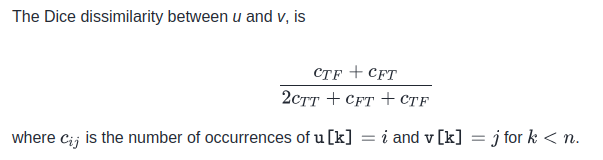
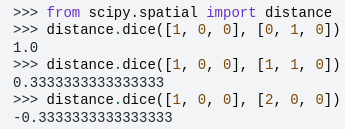
I don't get the distance, but it seems different

In [17]:
if LOTS_OF_TRAINING_TIME:
    model = LOF(metric='dice', contamination=0.05)
    model.fit(df)
    outliers["lof_dice"] = model.predict(df)

In [18]:
# outliers = np.ndarray([lof_outliers, lof_outliers2, lof_outliers3])
# outliers

# Hamming

The Hamming distance between 1-D arrays u and v, is simply the proportion of disagreeing components in u and v. 

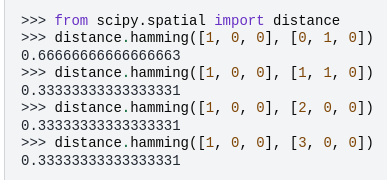

In [19]:
if RUN_OPTIONAL or LOTS_OF_TRAINING_TIME:
    model = LOF(metric='hamming', contamination=0.05)
    model.fit(df)
    outliers["lof_hamming"] = model.predict(df)

## Linear or PCA based

Principal component analysis (PCA) can be used in detecting outliers. PCA is a linear dimensionality reduction using Singular Value Decomposition of the data to project it to a lower dimensional space.

In this procedure, covariance matrix of the data can be decomposed to orthogonal vectors, called eigenvectors, associated with eigenvalues. The eigenvectors with high eigenvalues capture most of the variance in the data.

Therefore, a low dimensional hyperplane constructed by k eigenvectors can capture most of the variance in the data. However, outliers are different from normal data points, which is more obvious on the hyperplane constructed by the eigenvectors with small eigenvalues.

Therefore, outlier scores can be obtained as the sum of the projected distance of a sample on all eigenvectors.

In [20]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Example: Load a dataset (replace with your own dataset)
X = df

# Standardize the data (important for PCA)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 1: Fit PCA
pca = PCA()
pca.fit(X_scaled)

PCA()

In [21]:
# Step 2: Calculate cumulative variance
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance_ratio)
cumulative_variance



array([0.40046096, 0.61726811, 0.6421203 , 0.65308309, 0.66098365,
       0.66787026, 0.67467392, 0.67984183, 0.68492665, 0.68979421,
       0.69432442, 0.69844513, 0.70251568, 0.70652211, 0.71024457,
       0.71384967, 0.71735562, 0.72079529, 0.7240624 , 0.7272736 ,
       0.73040729, 0.73345435, 0.73647662, 0.73942911, 0.74223957,
       0.74497433, 0.7476787 , 0.75035071, 0.75300118, 0.75562311,
       0.75820713, 0.76076913, 0.76328268, 0.7657795 , 0.76823769,
       0.77066773, 0.77307569, 0.77544865, 0.77777192, 0.78007136,
       0.78235362, 0.78459429, 0.78682158, 0.78904289, 0.79122059,
       0.79336963, 0.79550125, 0.79757915, 0.79965   , 0.8016858 ,
       0.80370536, 0.80569711, 0.80767585, 0.8096281 , 0.81154741,
       0.81341798, 0.81528121, 0.81709249, 0.81889453, 0.82068032,
       0.82244125, 0.82418923, 0.82592473, 0.82764168, 0.82934104,
       0.8310301 , 0.83265993, 0.83427681, 0.83588526, 0.83748143,
       0.83905989, 0.84063164, 0.84218413, 0.84371456, 0.84521

In [22]:
explained_variance_ratio

array([4.00460957e-01, 2.16807154e-01, 2.48521857e-02, 1.09627939e-02,
       7.90056408e-03, 6.88660340e-03, 6.80365882e-03, 5.16791542e-03,
       5.08482137e-03, 4.86756121e-03, 4.53020462e-03, 4.12070956e-03,
       4.07054954e-03, 4.00643486e-03, 3.72245540e-03, 3.60510452e-03,
       3.50595106e-03, 3.43967087e-03, 3.26710377e-03, 3.21120314e-03,
       3.13368536e-03, 3.04706338e-03, 3.02227347e-03, 2.95248453e-03,
       2.81046087e-03, 2.73475608e-03, 2.70437714e-03, 2.67200589e-03,
       2.65047557e-03, 2.62192697e-03, 2.58401536e-03, 2.56200442e-03,
       2.51355345e-03, 2.49681357e-03, 2.45818952e-03, 2.43003955e-03,
       2.40796443e-03, 2.37296079e-03, 2.32326343e-03, 2.29944307e-03,
       2.28226369e-03, 2.24066757e-03, 2.22728605e-03, 2.22131389e-03,
       2.17769663e-03, 2.14904592e-03, 2.13162071e-03, 2.07789625e-03,
       2.07085148e-03, 2.03580360e-03, 2.01955556e-03, 1.99175087e-03,
       1.97873882e-03, 1.95225337e-03, 1.91930189e-03, 1.87057078e-03,
      

In [23]:
# Step 3: Find number of components that explain 95% variance
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1  # Add 1 since index starts from 0

print(f"Number of components to explain 95% variance: {n_components_95}")
print("Explained variance ratio for each component:")
for i, var in enumerate(explained_variance_ratio, 1):
    print(f"PC-{i}: {var:.4f}")


Number of components to explain 95% variance: 206
Explained variance ratio for each component:
PC-1: 0.4005
PC-2: 0.2168
PC-3: 0.0249
PC-4: 0.0110
PC-5: 0.0079
PC-6: 0.0069
PC-7: 0.0068
PC-8: 0.0052
PC-9: 0.0051
PC-10: 0.0049
PC-11: 0.0045
PC-12: 0.0041
PC-13: 0.0041
PC-14: 0.0040
PC-15: 0.0037
PC-16: 0.0036
PC-17: 0.0035
PC-18: 0.0034
PC-19: 0.0033
PC-20: 0.0032
PC-21: 0.0031
PC-22: 0.0030
PC-23: 0.0030
PC-24: 0.0030
PC-25: 0.0028
PC-26: 0.0027
PC-27: 0.0027
PC-28: 0.0027
PC-29: 0.0027
PC-30: 0.0026
PC-31: 0.0026
PC-32: 0.0026
PC-33: 0.0025
PC-34: 0.0025
PC-35: 0.0025
PC-36: 0.0024
PC-37: 0.0024
PC-38: 0.0024
PC-39: 0.0023
PC-40: 0.0023
PC-41: 0.0023
PC-42: 0.0022
PC-43: 0.0022
PC-44: 0.0022
PC-45: 0.0022
PC-46: 0.0021
PC-47: 0.0021
PC-48: 0.0021
PC-49: 0.0021
PC-50: 0.0020
PC-51: 0.0020
PC-52: 0.0020
PC-53: 0.0020
PC-54: 0.0020
PC-55: 0.0019
PC-56: 0.0019
PC-57: 0.0019
PC-58: 0.0018
PC-59: 0.0018
PC-60: 0.0018
PC-61: 0.0018
PC-62: 0.0017
PC-63: 0.0017
PC-64: 0.0017
PC-65: 0.0017
PC-6

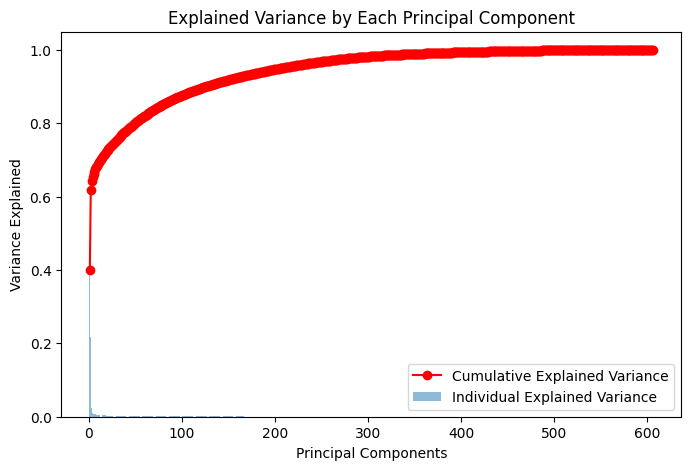

In [24]:

# Step 4: Plot explained variance for each component
plt.figure(figsize=(8, 5))
plt.bar(range(1, len(explained_variance_ratio) + 1), explained_variance_ratio, alpha=0.5, label="Individual Explained Variance")
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='r', label="Cumulative Explained Variance")
plt.xlabel('Principal Components')
plt.ylabel('Variance Explained')
plt.title('Explained Variance by Each Principal Component')
plt.legend()
plt.show()



In [25]:
# Step 5: Use only the first `n_components_95` components
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)



In [26]:
# n_components_95

In [27]:
from pyod.models.pca import PCA as pyodPCA

In [28]:
model = pyodPCA(n_components=0.95, svd_solver="full", contamination=0.05)
model.fit(df)
outliers["pca"] = model.predict(df)
outliers["pca"]

array([0, 0, 0, ..., 0, 0, 0])

In [29]:
# copod = COPOD(contamination=0.05)
# copod.fit(df)

In [30]:
# outliers["copod"] = copod.predict(df)

In [31]:
# minimum 44 min
if LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05)
    model.fit(df)
    outliers["knn"] = model.predict(df)
    outliers["knn"]

In [32]:
if RUN_OPTIONAL or LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05, method='average')
    model.fit(df)
    outliers["knn_average"] = model.predict(df)
    outliers["knn_average"]

In [33]:
if LOTS_OF_TRAINING_TIME:
    model = KNN(contamination=0.05, n_neighbors=8)
    model.fit(df)
    outliers["knn_largest_8"] = model.predict(df)
    outliers["knn_largest_8"]

In [34]:
model = IForest(contamination=0.05)
model.fit(df)
outliers["iforest"] = model.predict(df)
outliers["iforest"]

/home/miked/code/dep2-g2/venv/lib/python3.12/site-packages/sklearn/base.py:486: UserWarning: X has feature names, but IsolationForest was fitted without feature names
  warnings.warn(


array([0, 0, 0, ..., 0, 0, 0])

In [35]:
model = DIF(contamination=0.05)
model.fit(df)
outliers["deep_iforest"] = model.predict(df)
outliers["deep_iforest"]

array([0, 0, 0, ..., 0, 0, 0])

## Wanna try-out
 
- ABOD (Angle based outlier detection) or FastABOD
- COPOD
- KNN
- IForest


In [36]:
outliers

{'TestKey': [183639,
  183640,
  183641,
  183642,
  183643,
  183644,
  183646,
  183647,
  183648,
  183649,
  183650,
  183651,
  183652,
  183655,
  183656,
  183657,
  183658,
  183659,
  183660,
  183661,
  183663,
  183664,
  183665,
  183666,
  183667,
  183668,
  183669,
  183672,
  183673,
  183674,
  183675,
  183679,
  183683,
  183684,
  183686,
  183688,
  183693,
  183696,
  183703,
  183704,
  183705,
  183707,
  183708,
  183710,
  183712,
  183713,
  183714,
  183715,
  183716,
  183720,
  183726,
  183733,
  183736,
  183744,
  183746,
  183749,
  183759,
  183760,
  183768,
  183779,
  183799,
  183802,
  183806,
  183819,
  183846,
  183853,
  183862,
  183872,
  183954,
  183999,
  184364,
  201193,
  201670,
  201710,
  201782,
  201786,
  201880,
  201882,
  201883,
  201884,
  201886,
  201887,
  201888,
  201889,
  201892,
  201897,
  201898,
  201899,
  201901,
  201903,
  201909,
  201910,
  201911,
  201912,
  201914,
  201915,
  201917,
  201920,
  201921,

In [37]:
df_outliers = pd.DataFrame(outliers)
columns = df_outliers.columns.to_list()
columns.remove("TestKey")
df_outliers['count'] =  df_outliers[columns].sum(axis=1)
df_outliers['pyod % outlier'] = df_outliers['count'] / len(columns)
df_outliers

,TestKey,lof,pca,iforest,deep_iforest,count,pyod % outlier
0,183639,0,0,0,0,0,0.00
1,183640,0,0,0,0,0,0.00
2,183641,0,0,0,0,0,0.00
3,183642,0,0,0,0,0,0.00
4,183643,0,0,0,0,0,0.00
...,...,...,...,...,...,...,...
21189,255089,0,0,0,0,0,0.00
21190,255095,0,0,0,0,0,0.00
21191,255098,0,0,0,0,0,0.00
21192,255099,1,0,0,0,1,0.25


In [38]:
df_outliers['count'].value_counts()

count
0    18221
1     1935
2      960
3       69
4        9
Name: count, dtype: int64

In [49]:
TRESHOLD = 0.5
df_outliers["is_anomaly"] = np.where(df_outliers['pyod % outlier'] >= TRESHOLD, 1, 0)
df_outliers

,TestKey,lof,pca,iforest,deep_iforest,count,pyod % outlier,is_anomaly
0,183639,0,0,0,0,0,0.00,0
1,183640,0,0,0,0,0,0.00,0
2,183641,0,0,0,0,0,0.00,0
3,183642,0,0,0,0,0,0.00,0
4,183643,0,0,0,0,0,0.00,0
...,...,...,...,...,...,...,...,...
21189,255089,0,0,0,0,0,0.00,0
21190,255095,0,0,0,0,0,0.00,0
21191,255098,0,0,0,0,0,0.00,0
21192,255099,1,0,0,0,1,0.25,0


In [50]:
df_outliers.to_csv("csv/pyod_ensemble.csv", index=False)

In [51]:
df_outliers["is_anomaly"].sum()

np.int64(1038)